In [31]:
#Import Libraries
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
#Dataset load karenge
df = pd.read_csv(r"C:\Users\nishika tendane\Downloads\archive (3)\car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [39]:
#Dataset ka size check karo
df.shape

(301, 9)

In [41]:
#Column details check karo
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [43]:
#Missing values check karo
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [45]:
#Dataset ka statistical analysis
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [47]:
#Categorical data convert karna
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [49]:
#Features aur Target banayenge
X = df.drop(['Selling_Price','Car_Name'], axis=1)

y = df['Selling_Price']

In [51]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [59]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

In [61]:
df['Fuel_Type'] = df['Fuel_Type'].map({
    'Petrol':0,
    'Diesel':1,
    'CNG':2
})

df['Seller_Type'] = df['Seller_Type'].map({
    'Dealer':0,
    'Individual':1
})

df['Transmission'] = df['Transmission'].map({
    'Manual':0,
    'Automatic':1
})

In [63]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [65]:
X = df.drop(['Selling_Price','Car_Name'], axis=1)

y = df['Selling_Price']

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [69]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [71]:
#Prediction karo
y_pred = model.predict(X_test)

y_pred[:5]

array([ 2.96670467,  8.3025584 ,  6.05620758, -1.46814968,  9.25713882])

In [73]:
#Actual vs Predicted check karo
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head()

,Actual Price,Predicted Price
177,0.35,2.966705
289,10.11,8.302558
228,4.95,6.056208
198,0.15,-1.468150
60,6.95,9.257139


In [75]:
#Model Accuracy Check karo
print("MAE:", mean_absolute_error(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.2217615462344986
MSE: 3.528927253903051
R2 Score: 0.8468053957652042


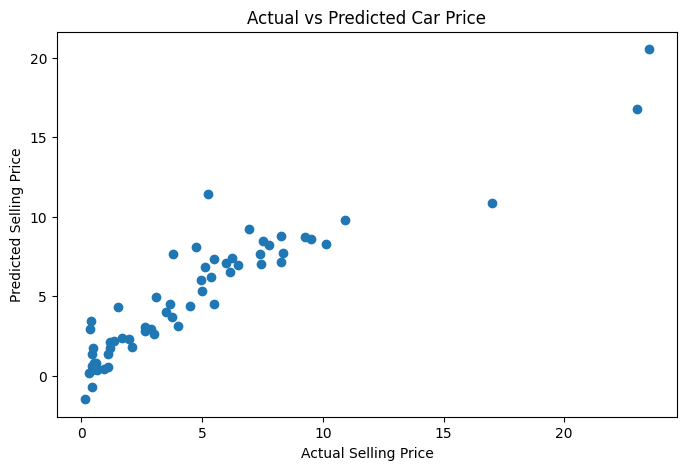

In [77]:
#Graph banayenge
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.title("Actual vs Predicted Car Price")

plt.show()

In [79]:
#Model ka R2 Score check karo
print("MAE:", mean_absolute_error(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.2217615462344986
MSE: 3.528927253903051
R2 Score: 0.8468053957652042


In [81]:
#New Car Price Prediction
model.predict([[2015, 5.5, 30000, 0, 0, 0, 0]])

C:\Users\nishika tendane\Anaconda3\python\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4.27141664])

In [83]:
#Model Save karna
import pickle

pickle.dump(model, open("car_price_model.pkl","wb"))

In [85]:
#Model Save karo
import pickle

pickle.dump(model, open("car_price_model.pkl","wb"))

In [87]:
import pickle

pickle.dump(model, open("car_price_model.pkl","wb"))

In [89]:
import os

os.listdir()

['.anaconda',
 '.conda',
 '.condarc',
 '.continuum',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.VirtualBox',
 '.virtual_documents',
 '.vscode',
 '.vscode-shared',
 'actors.sql',
 'Anaconda3',
 'AppData',
 'Application Data',
 'car_price_model.pkl',
 'Car_Price_Prediction.ipynb',
 'Car_Price_Prediction.ipynb.ipynb',
 'cleaned_news_dataset.csv',
 'Contacts',
 'Cookies',
 'customer_purchases.db',
 'Documents',
 'Downloads',
 'fake&realdataset.ipynb',
 'fake-news-detection.ipynb',
 'Favorites',
 'hr.sql nishika.sql',
 'Links',
 'Local Settings',
 'movie data analysis netflix.ipynb',
 'Music',
 'My Documents',
 'mymoviesdb.csv',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{ea450a68-f7e1-11ee-af11-e86538e07586}.TM.blf',
 'NTUSER.DAT{ea450a68-f7e1-11ee-af11-e86538e07586}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{ea450a68-f7e1-11ee-af11-e86538e07586}.TMContainer00000000000000000002.regtrans-m